This notebook is an initial demo showing how the ZCU can send a signal from its DAC to its ADC, and what it looks like to graph the frequency sent vs the magnitude.

We will be using tProc channel 7: DAC 229 CH3 <-> Readout channel 0 : ADC 224 CH0 (*TODO* Check that this maps to our balun adapter)

In [135]:
import pynq
from qick import *
from tqdm.notebook import tqdm
%pylab inline

Populating the interactive namespace from numpy and matplotlib


/usr/local/share/pynq-venv/lib/python3.8/site-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['datetime', 'f']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [141]:
# Load bitstream with custom overlay
soc = QickSoc()
# Since we're running locally on the QICK, we don't need a separate QickConfig object.
# See other demos for more info on that
soccfg = soc
print(soccfg)

QICK running on ZCU216, software version 0.2.396

Firmware configuration (built Mon Aug 21 11:09:34 2023):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc clock, DAC tile 2], [DAC tile 3], [ADC tile 2]

	7 signal generator channels:
	0:	axis_signal_gen_v6 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory: 65536 complex samples (9.524 us)
		32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_signal_gen_v6 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory: 65536 complex samples (9.524 us)
		32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 1 is 1_230 on JHC4, or QICK box DAC port 9
	2:	axis_signal_gen_v6 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory: 65536 complex samples (9.524 us)
		32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 2 is 2_230 on JHC3, or QICK box DAC port 10
	3:	axis_signal_gen_v6 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory

We create a LoopbackProgram class which takes advantage of AveragerProgram. This comes directly from the "02_Sweeping_variables" demo. It allows us to sweep the frequency using Python instead of QICK. Do note that this is slower than using QICK, but good enough for our current purposes.

In [137]:
class LoopbackProgram(AveragerProgram):
    def initialize(self):
        cfg=self.cfg   

        # set the nyquist zone
        self.declare_gen(ch=cfg["res_ch"], nqz=1)

        #configure the readout lengths and downconversion frequencies
        self.declare_readout(ch=cfg["ro_ch"], length=self.cfg["readout_length"],
                             freq=self.cfg["pulse_freq"], gen_ch=cfg["res_ch"])

        freq=self.freq2reg(cfg["pulse_freq"], gen_ch=cfg["res_ch"], ro_ch=cfg["ro_ch"])  # convert frequency to dac frequency (ensuring it is an available adc frequency)
        self.set_pulse_registers(ch=cfg["res_ch"], style="const", freq=freq, phase=0, gain=cfg["pulse_gain"], 
                                 length=cfg["length"])
        self.synci(200)  # give processor some time to configure pulses
    
    def body(self):
        self.measure(pulse_ch=self.cfg["res_ch"], 
             adcs=[self.cfg["ro_ch"]],
             adc_trig_offset=self.cfg["adc_trig_offset"],
             wait=True,
             syncdelay=self.us2cycles(self.cfg["relax_delay"]))

Build the config object we will pass to LoopbackProgram

In [142]:
config={"res_ch":0, # --Fixed DAC channel
        "ro_ch":0, # --Fixed ADC channel
        "relax_delay":1, # --Fixed
        "res_phase":0, # --Fixed
        "pulse_style": "const", # --Fixed
        "length":200, # [Clock ticks]        
        "readout_length":200, # [Clock ticks]
        "pulse_gain":5000, # [DAC units]
        "pulse_freq": 100, # [MHz] we will overwrite this in our loop
        "adc_trig_offset": 100, # [Clock ticks]
        "reps":1000, 
       }

Get the magnitudes

In [143]:
# Define frequency range
freqs = np.linspace(10, 900, 179)  # MHz, staying under 1 GHz
mags = []

for f in freqs:
    config['pulse_freq'] = f # Loop through frequency values
    prog = LoopbackProgram(soccfg, config)
    avg_data = prog.acquire(soc, progress=False)
    I = prog.di_buf[0] / (config['readout_length'] * config['reps'])
    Q = prog.dq_buf[0] / (config['readout_length'] * config['reps'])
    mags.append(np.abs(I + 1j*Q))

Finally we plot frequency vs. magnitude

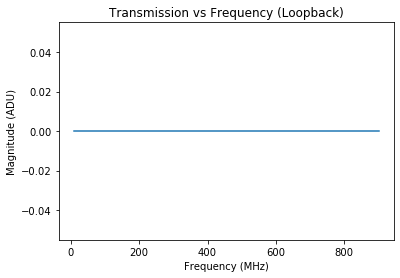

In [144]:
plt.plot(freqs, mags)
plt.xlabel('Frequency (MHz)')
plt.ylabel('Magnitude (ADU)')
plt.title('Transmission vs Frequency (Loopback)')
plt.show()